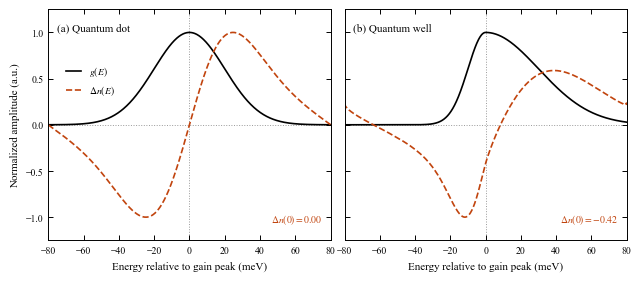

In [2]:
"""
plot_qd_qw_alpha_figure.py

Reproduces a two-panel figure illustrating why the linewidth enhancement
factor (alpha-factor) is intrinsically smaller for quantum dot (QD) lasers
than for quantum well (QW) lasers.

Physics
-------
The refractive index change Delta n(E) and the optical gain g(E) are the
real and imaginary parts of the same complex susceptibility, related by
the Kramers-Kronig (Hilbert) transform:

    Delta n(E)  ~  (1/pi) * P.V. Integral[ g(E') / (E' - E) dE' ]

The Hilbert transform of an even (symmetric) function about a point is
odd (antisymmetric) about that point, and therefore vanishes exactly
there. QD gain spectra are close to symmetric (Gaussian, set by dot-size
dispersion), so Delta n crosses zero at the gain peak, i.e. at the lasing
photon energy -> d(Delta n)/dN ~ 0 -> small alpha. QW gain spectra are
asymmetric (2D step-DOS convolved with Fermi-Dirac occupation), so the
zero crossing of Delta n is displaced from the gain peak, leaving a
finite slope, and a larger alpha.

Note: g(E) and Delta n(E) are independently normalized for display. This
is a schematic illustration of the Kramers-Kronig relationship, not a
quantitative gain/index calculation for a specific material system.

Output
------
Saves qd_vs_qw_gain_index.pdf (vector) and qd_vs_qw_gain_index.png
(raster, 600 dpi), figure width = 6.3 in.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# ---------------------------------------------------------------------
# Publication-style rcParams
# ---------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "pdf.fonttype": 42,   # embed real fonts, not Type 3 (required by most journals)
    "ps.fonttype": 42,
})

# ---------------------------------------------------------------------
# Build symmetric (QD) and asymmetric (QW) gain lineshapes
# ---------------------------------------------------------------------
E = np.linspace(-80, 80, 801)  # meV, relative to the gain peak


def gaussian(E, sigma):
    return np.exp(-(E ** 2) / (2 * sigma ** 2))


g_qd = gaussian(E, sigma=20)                                             # symmetric
g_qw = np.where(E < 0, gaussian(E, sigma=10), gaussian(E, sigma=30))     # asymmetric


def kk_index_change(g):
    """Hilbert transform of g, used as a schematic proxy for the
    Kramers-Kronig-derived refractive index change, normalized to unit
    peak amplitude for display."""
    dn = np.imag(hilbert(g))
    return dn / np.max(np.abs(dn))


dn_qd = kk_index_change(g_qd)
dn_qw = kk_index_change(g_qw)

i0 = np.argmin(np.abs(E))  # index of E = 0, the gain peak

# ---------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.75), sharey=True, sharex=True)

panel_labels = ["(a) Quantum dot", "(b) Quantum well"]
gain_curves = [g_qd, g_qw]
dn_curves = [dn_qd, dn_qw]

for ax, g, dn, label in zip(axes, gain_curves, dn_curves, panel_labels):
    ax.axvline(0, color="0.6", lw=0.7, ls=":", zorder=1)
    ax.axhline(0, color="0.6", lw=0.7, ls=":", zorder=1)

    ax.plot(E, g, color="k", ls="-", label=r"$g(E)$")
    ax.plot(E, dn, color="#c1440e", ls="--", label=r"$\Delta n(E)$")

    ax.set_xlim(-80, 80)
    ax.set_ylim(-1.25, 1.25)
    ax.set_xlabel("Energy relative to gain peak (meV)")

    ax.text(0.03, 0.94, label, transform=ax.transAxes,
            ha="left", va="top", fontsize=8)
    ax.text(0.97, 0.06, rf"$\Delta n(0) = {dn[i0]:.2f}$",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=7, color="#c1440e")

axes[0].set_ylabel("Normalized amplitude (a.u.)")
axes[0].legend(loc="upper left", bbox_to_anchor=(0.03, 0.80),
               frameon=False, handlelength=1.6)

fig.tight_layout(pad=0.6, w_pad=1.2)

fig.savefig(r"C:\Users\josep\Documents\MRes mini-project 2\Figures\Ultra-stable-lasers-and-photonic-integrated-circuits-for-secure-communications\content\Figures\Theory\qd_vs_qw_gain_index.pdf", bbox_inches="tight")
fig.savefig("qd_vs_qw_gain_index.png", dpi=600, bbox_inches="tight")

plt.show()

In [3]:
maj_tick_width = 0.8
min_tick_width = 0.8

plot_params = { "figure.dpi": "200", "axes.labelsize": 14, "axes.linewidth": 1.5, "axes.titlesize": 20, "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.title_fontsize": 11, "legend.fontsize": 11, "xtick.major.size": 3.5, "xtick.major.width": maj_tick_width, "xtick.minor.size": 2.5, "xtick.minor.width": min_tick_width, "ytick.major.size": 3.5, "ytick.major.width": maj_tick_width, "ytick.minor.size": 2.5, "ytick.minor.width": min_tick_width, "font.family": "serif", "text.usetex": True, "xtick.direction": "in","ytick.direction": "in", "pgf.texsystem": "pdflatex","font.family": "serif", "text.usetex": True, "pgf.rcfonts": False,}

plt.rcParams.update(plot_params)

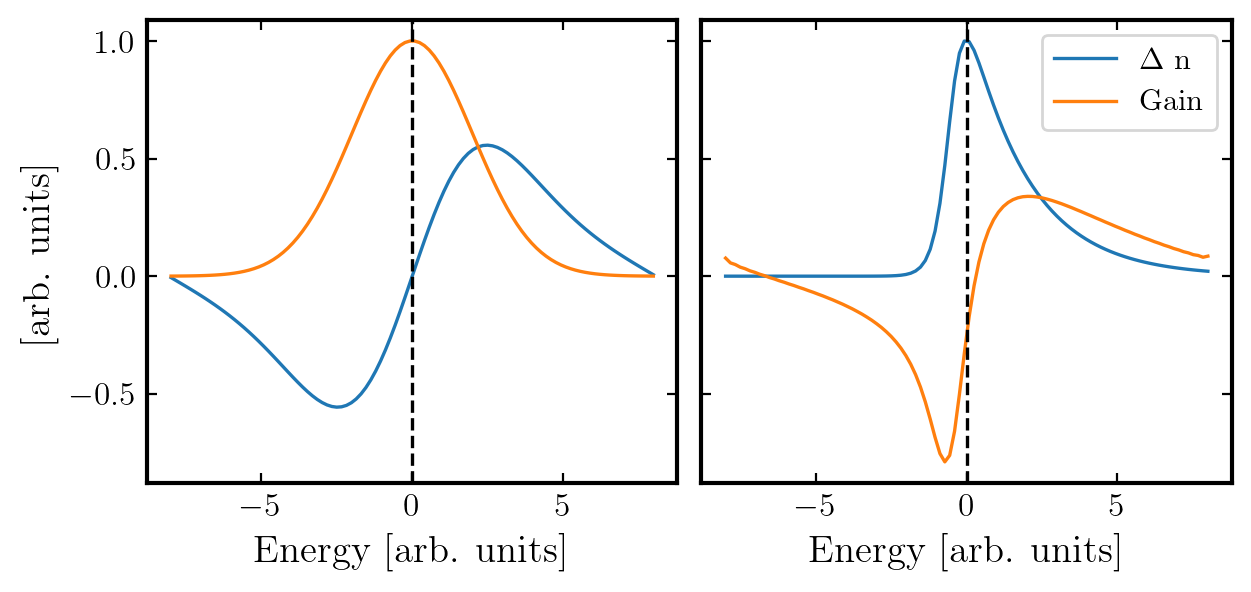

In [5]:
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import numpy as np

x_values_1 = np.linspace(-8,8,100)

def gaussian(x, mu, sig):
    return (
        1.0 / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )
y_values_1 =  gaussian(x_values_1, 0, 2)
y_values_1 = y_values_1/np.amax(y_values_1)

kk_gaussian = hilbert(y_values_1)

fig,ax = plt.subplots(1,2,figsize = (6.3,3), sharey=True)

ax[0].plot(x_values_1,np.imag(kk_gaussian))
ax[0].plot(x_values_1, y_values_1)
ax[0].axvline(0,linestyle = 'dashed',color='black')

x_values_2 = np.linspace(-8,8,100)
boltzmann = np.exp(-x_values_2/2)
sigmoid = 1-(1/(1 + np.exp(4*(x_values_2+0.5))))

y_values_2 = sigmoid*boltzmann
y_values_2 = y_values_2/np.amax(y_values_2)
kk_qw = hilbert(y_values_2)

ax[1].plot(x_values_2,y_values_2, label = r'$\Delta$ n')
ax[1].plot(x_values_2,np.imag(kk_qw), label = 'Gain')
ax[1].axvline(0,linestyle = 'dashed',color='black')
ax[1].legend()

ax[0].set_ylabel('[arb. units]')
ax[0].set_xlabel('Energy [arb. units]')
ax[1].set_xlabel('Energy [arb. units]')

fig.tight_layout()
plt.savefig(r'C:\Users\josep\Documents\MRes mini-project 2\Figures\Ultra-stable-lasers-and-photonic-integrated-circuits-for-secure-communications\content\Figures\pgf_figures\kramers_konig.pgf')
plt.show()


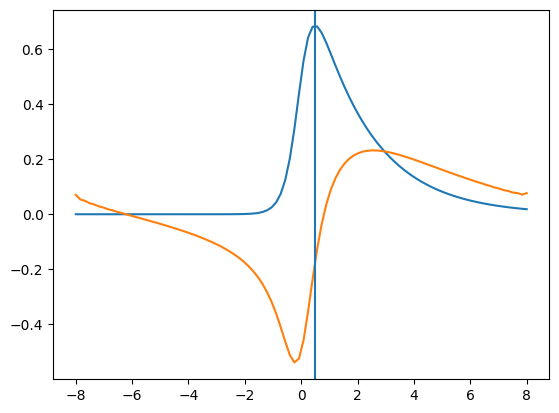

In [ ]:
x_values_2 = np.linspace(-8,8,100)
boltzmann = np.exp(-x_values_2/2)
sigmoid = 1-(1/(1 + np.exp(4*x_values_2)))

y_values_2 = sigmoid*boltzmann
kk_qw = hilbert(y_values_2)

plt.plot(x_values_2,y_values_2)
plt.plot(x_values_2,np.imag(kk_qw))
plt.axvline(0.5)
plt.show()